In [1]:
from pyspark.sql import SparkSession

spark = (
        SparkSession.builder
        .appName("fintek_analytics")
        .master("spark://spark-master:7077")

        .config("spark.executor.memory", "2g")
        .config("spark.driver.memory", "1g")
        .config("spark.executor.cores", 2)
        .config("spark.sql.shuffle.partitions", 10)

        .config("spark.driver.host", "fintek-jupyter")
        .config("spark.driver.bindAddress", "0.0.0.0")

        .config("spark.jars.packages", "org.postgresql:postgresql:42.7.3")

        .getOrCreate()
    )

:: loading settings :: url = jar:file:/opt/conda/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/jovyan/.ivy2.5.2/cache
The jars for the packages stored in: /home/jovyan/.ivy2.5.2/jars
org.postgresql#postgresql added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-4d0659b4-93d8-4919-a9a9-01222f0c830f;1.0
	confs: [default]
	found org.postgresql#postgresql;42.7.3 in central
	found org.checkerframework#checker-qual;3.42.0 in central
:: resolution report :: resolve 82ms :: artifacts dl 1ms
	:: modules in use:
	org.checkerframework#checker-qual;3.42.0 from central in [default]
	org.postgresql#postgresql;42.7.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------

In [5]:
jdbc_url = "jdbc:postgresql://fintek-postgres:5432/fintek_db"

properties = {
    "user": "finance",
    "password": "finance123",
    "driver": "org.postgresql.Driver"
}

try:
    print("Veriler veritabanından okunuyor...")

    sql_prices = spark.read.jdbc(
    url=jdbc_url,
    table="""
    (   SELECT
            a.ticker,
            p.price_time,
            p.close,
            a.asset_type
        FROM prices p
        JOIN assets a
            ON p.asset_id = a.asset_id
        WHERE p.price_time >= '2024-01-01'
    ) AS index_prices
    """,
    properties=properties
)


    sql_returns = spark.read.jdbc(
    url=jdbc_url,
    table="""
    (   SELECT
            a.ticker,
            r.return_time,
            r.log_return,
            a.asset_type
        FROM returns r
        JOIN assets a
            ON r.asset_id = a.asset_id
        WHERE r.return_time >= '2024-01-01'
    ) AS index_returns
    """,
    properties=properties
)
    



    print("\n--- Prices ---")
    sql_prices.show(5)

    print("\n--- Returns ---")
    sql_returns.show(5)

except Exception as e:
    print(f"Veritabanına bağlanırken bir hata oluştu: {e}")

Veriler veritabanından okunuyor...

--- Prices ---
+------+----------+------------------+----------+
|ticker|price_time|             close|asset_type|
+------+----------+------------------+----------+
|  AAPL|2024-01-02|183.73129272460938|    equity|
|  MSFT|2024-01-02| 364.5894470214844|    equity|
|  NVDA|2024-01-02|48.141178131103516|    equity|
|  AMZN|2024-01-02|149.92999267578125|    equity|
| GOOGL|2024-01-02|137.03738403320312|    equity|
+------+----------+------------------+----------+
only showing top 5 rows

--- Returns ---
+------+-----------+--------------------+----------+
|ticker|return_time|          log_return|asset_type|
+------+-----------+--------------------+----------+
|  AAPL| 2024-01-02| -0.0364427210521594|    equity|
|  MSFT| 2024-01-02|-0.01384403512257...|    equity|
|  NVDA| 2024-01-02|-0.02772216679416184|    equity|
|  AMZN| 2024-01-02|  -0.013317252487413|    equity|
| GOOGL| 2024-01-02|-0.01094096408364...|    equity|
+------+-----------+--------------

In [16]:
import pandas as pd

print("Spark verileri Pandas formatına dönüştürülüyor...")

df_prices = sql_prices.toPandas()
df_returns = sql_returns.toPandas()


print("Veriler ayrıştırılıyor ve Pivot tablolara dönüştürülüyor...")

df_prices['price_time'] = pd.to_datetime(df_prices['price_time'])
df_returns['return_time'] = pd.to_datetime(df_returns['return_time'])


df_prices_indices = df_prices[df_prices['asset_type'] == 'index'].copy()
df_prices_stocks = df_prices[df_prices['asset_type'] == 'equity'].copy()

df_returns_indices = df_returns[df_returns['asset_type'] == 'index'].copy()
df_returns_stocks = df_returns[df_returns['asset_type'] == 'equity'].copy()



prices_index_pivot = df_prices_indices.pivot(
    index='price_time', columns='ticker', values='close'
).sort_index()

prices_stock_pivot = df_prices_stocks.pivot(
    index='price_time', columns='ticker', values='close'
).sort_index()

returns_index_pivot = df_returns_indices.pivot(
    index='return_time', columns='ticker', values='log_return'
).sort_index()

returns_stock_pivot = df_returns_stocks.pivot(
    index='return_time', columns='ticker', values='log_return'
).sort_index()

prices_index_pivot.columns.name = None
prices_stock_pivot.columns.name = None
returns_index_pivot.columns.name = None
returns_stock_pivot.columns.name = None

prices_index_pivot = prices_index_pivot.reset_index()
prices_stock_pivot = prices_stock_pivot.reset_index()
returns_index_pivot = returns_index_pivot.reset_index()
returns_stock_pivot = returns_stock_pivot.reset_index()


print("\n--- ENDEKS FİYATLARI (PİVOT) ---")
print(prices_index_pivot.head().to_string(index=False))

print("\n--- HİSSE FİYATLARI (PİVOT) ---")
print(prices_stock_pivot.head().to_string(index=False))

print("\n--- ENDEKS GETİRİLERİ (PİVOT) ---")
print(returns_index_pivot.head().to_string(index=False))

print("\n--- HİSSE GETİRİLERİ (PİVOT) ---")
print(returns_stock_pivot.head().to_string(index=False))

Spark verileri Pandas formatına dönüştürülüyor...
Veriler ayrıştırılıyor ve Pivot tablolara dönüştürülüyor...

--- ENDEKS FİYATLARI (PİVOT) ---
price_time          DJI       NASDAQ       SP500
2024-01-02 37715.039062 14765.940430 4742.830078
2024-01-03 37430.191406 14592.209961 4704.810059
2024-01-04 37440.339844 14510.299805 4688.680176
2024-01-05 37466.109375 14524.070312 4697.240234
2024-01-08 37683.011719 14843.769531 4763.540039

--- HİSSE FİYATLARI (PİVOT) ---
price_time       AAPL       AMZN       BAC      GOOGL         GS        JPM       MSFT      NVDA
2024-01-02 183.731293 149.929993 32.128777 137.037384 369.588898 163.843582 364.589447 48.141178
2024-01-03 182.355591 148.470001 31.778111 137.781250 363.392578 163.129486 364.324036 47.542511
2024-01-04 180.039658 144.570007 32.034000 135.271973 364.496735 164.212021 361.709076 47.971279
2024-01-05 179.317154 145.240005 32.631088 134.617371 367.818512 165.035919 361.522278 49.069660
2024-01-08 183.652130 149.100006 32.375191 1

Korelasyon matrisleri hesaplanıyor ve haritalar çiziliyor...



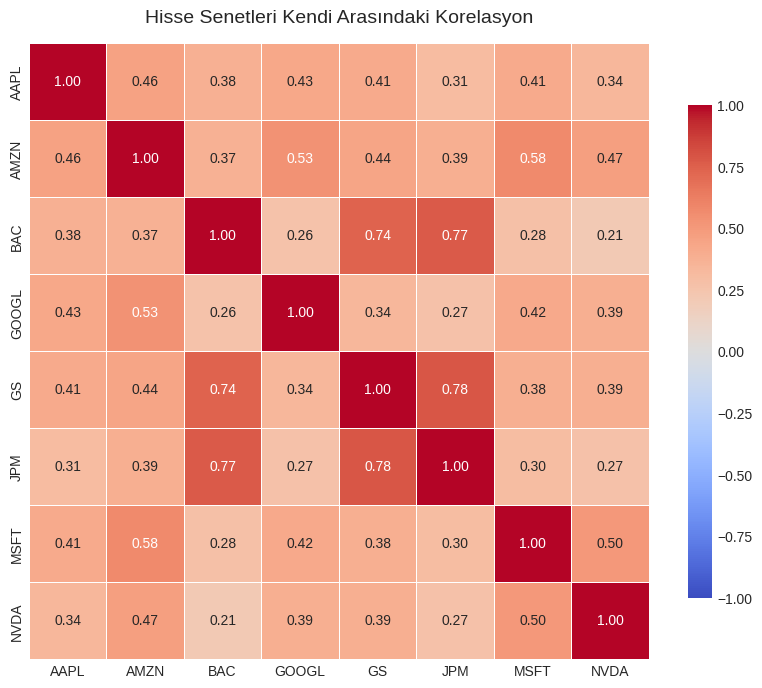

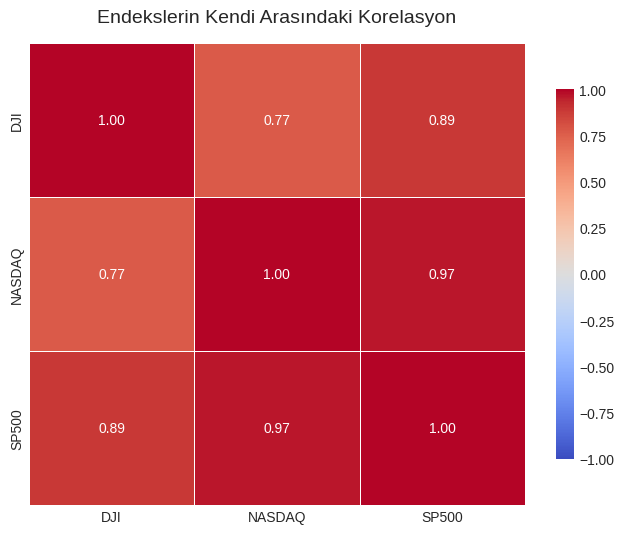

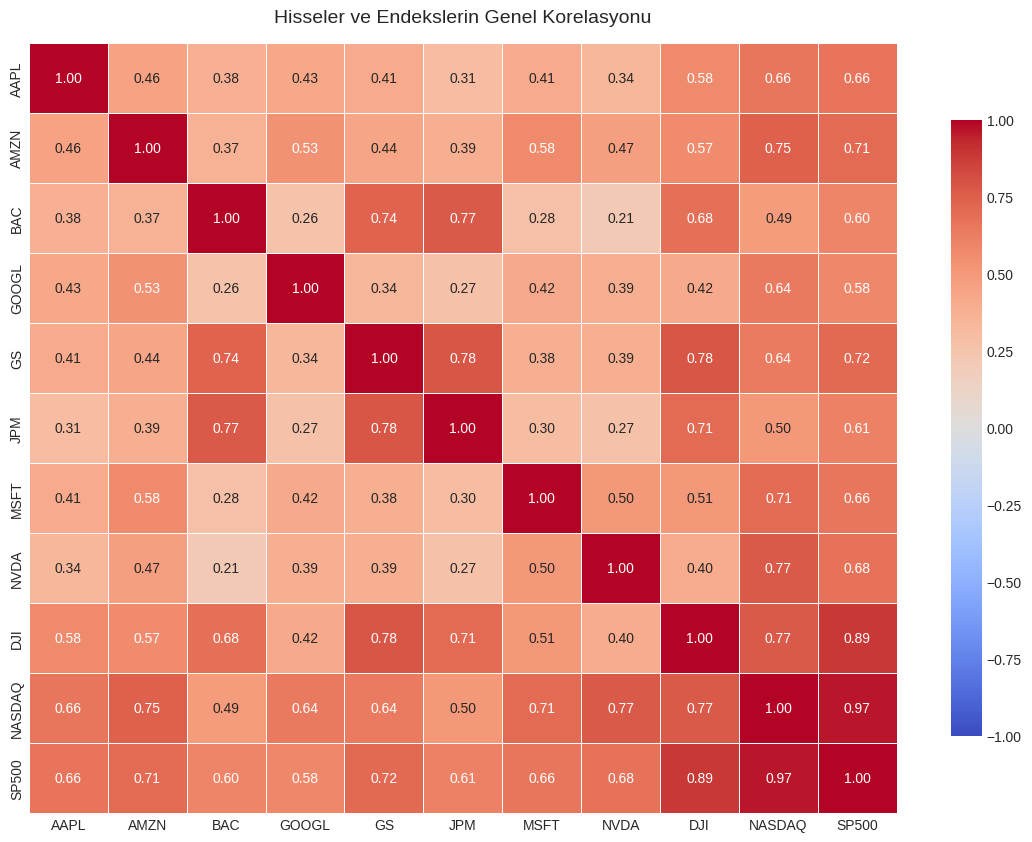

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Korelasyon matrisleri hesaplanıyor ve haritalar çiziliyor...\n")


corr_stocks = returns_stock_pivot.set_index('return_time').corr()

corr_indices = returns_index_pivot.set_index('return_time').corr()

returns_combined = pd.merge(
    returns_stock_pivot, 
    returns_index_pivot, 
    on='return_time', 
    how='inner' # Sadece iki tabloda da ortak olan günleri al
).set_index('return_time')

corr_combined = returns_combined.corr()


def draw_heatmap(corr_matrix, title, figsize=(10, 8)):
    plt.figure(figsize=figsize)
    # vmin=-1, vmax=1 : Renk skalasını tam olarak -1 (Tam Zıt) ile +1 (Tam Aynı) arasına sabitler
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
                vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title(title, fontsize=14, pad=15)
    plt.show()


draw_heatmap(corr_stocks, "Hisse Senetleri Kendi Arasındaki Korelasyon")

draw_heatmap(corr_indices, "Endekslerin Kendi Arasındaki Korelasyon", figsize=(8, 6))

draw_heatmap(corr_combined, "Hisseler ve Endekslerin Genel Korelasyonu", figsize=(14, 10))

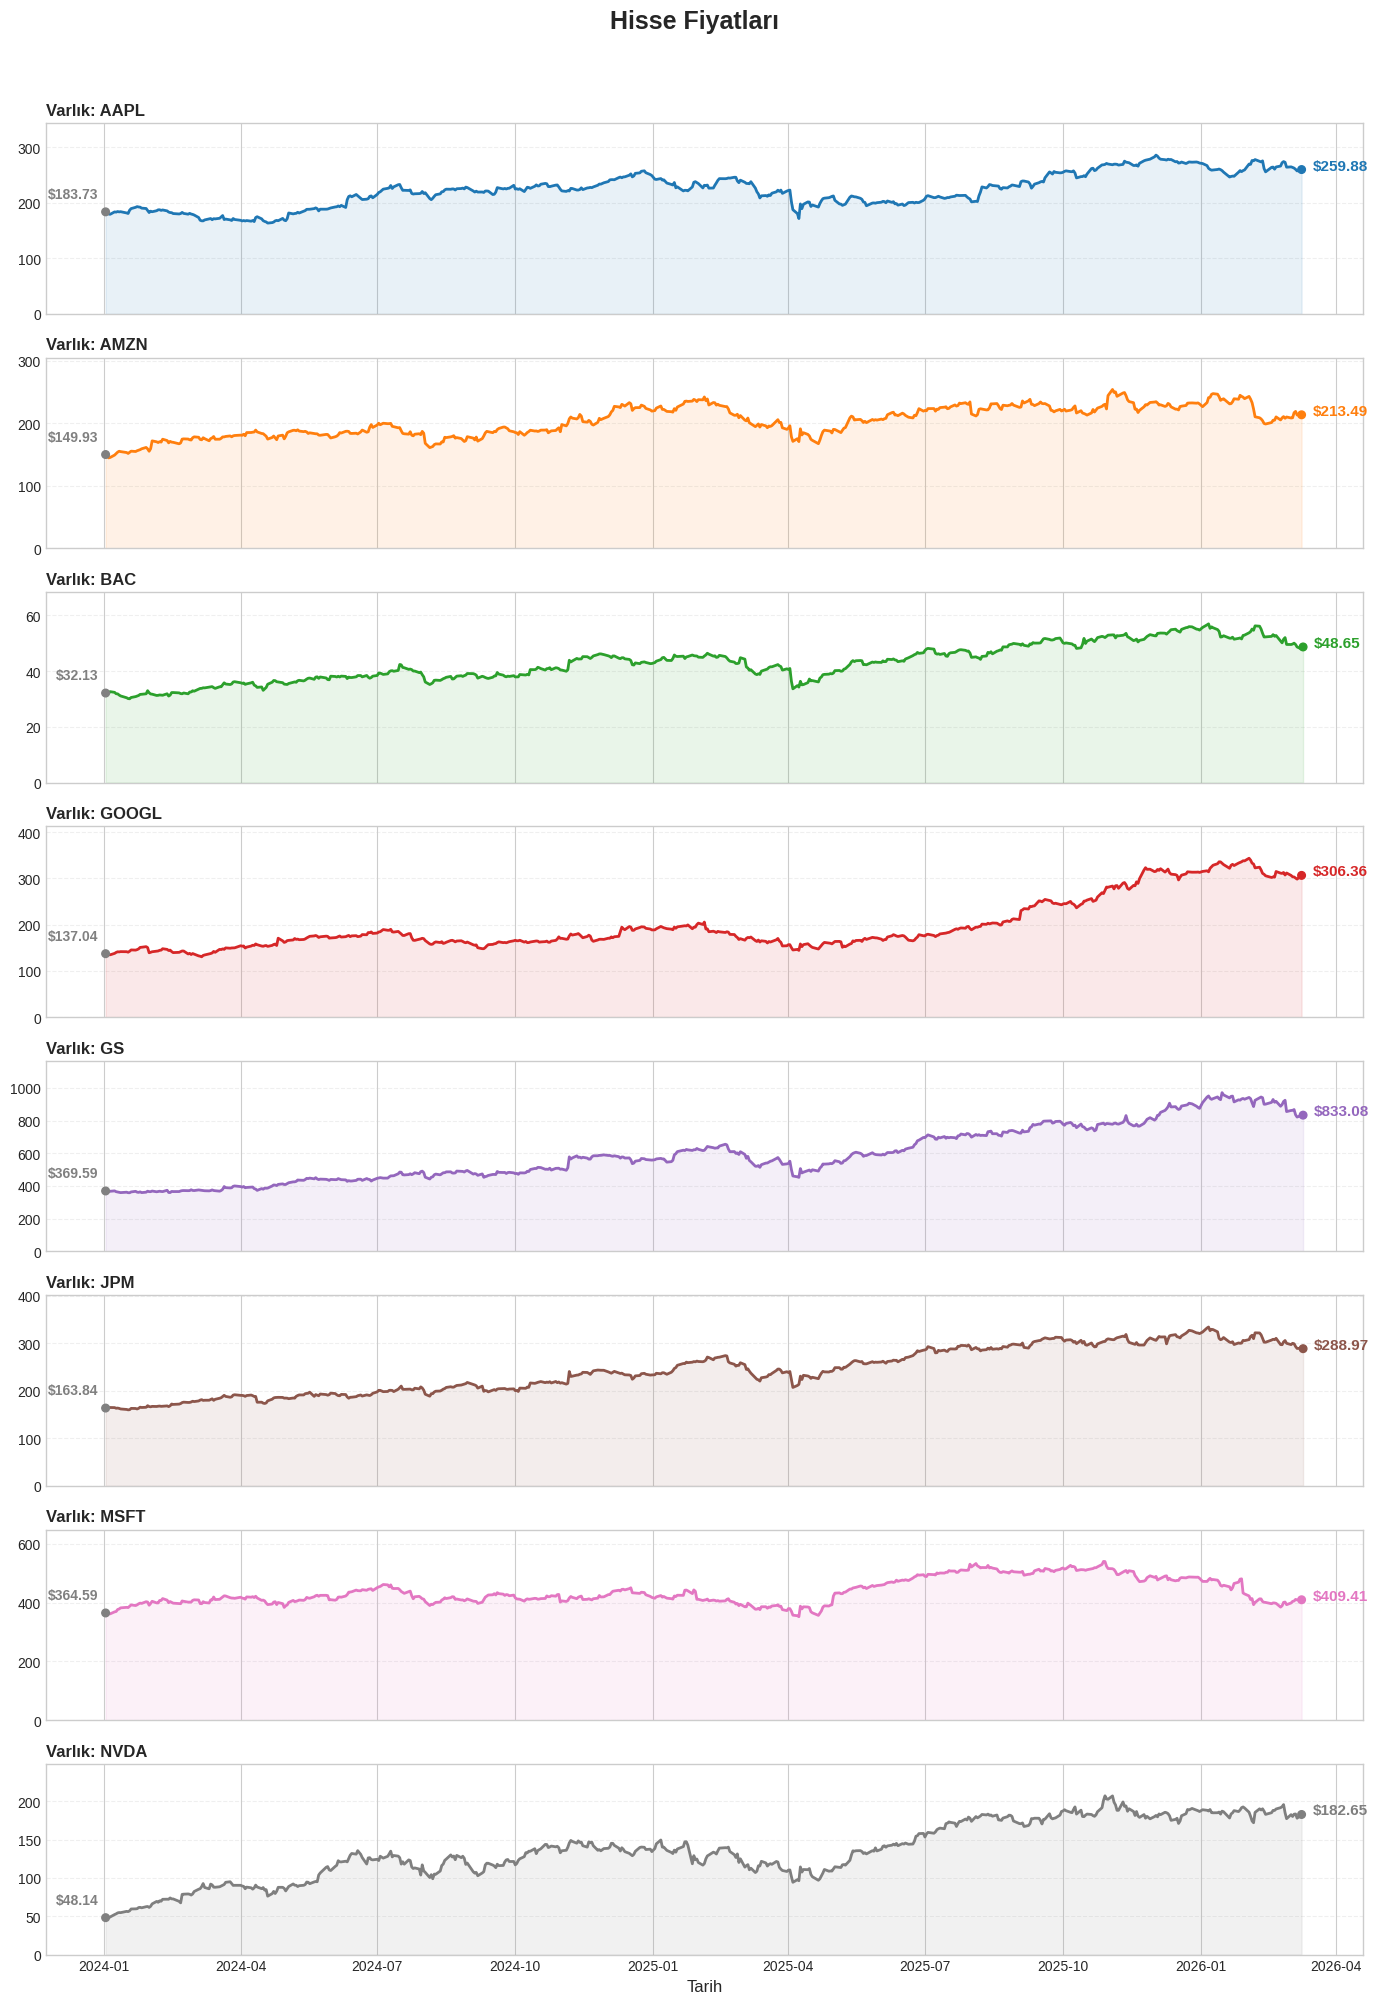

In [62]:
import matplotlib.pyplot as plt

def plot_subplots_with_start_end_prices(df, title, time_col):
    df_plot = df.set_index(time_col)
    num_cols = len(df_plot.columns)
    
    # fig objesini burada yakalıyoruz (suptitle için önemli)
    fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(14, 2.5 * num_cols), sharex=True)
    
    if num_cols == 1:
        axes = [axes]
    
    for i, column in enumerate(df_plot.columns):
        data = df_plot[column]
        valid_data = data.dropna()
        
        if not valid_data.empty:
            first_date, first_price = valid_data.index[0], valid_data.iloc[0]
            last_date, last_price = valid_data.index[-1], valid_data.iloc[-1]
            y_max = data.max()
            
            axes[i].plot(df_plot.index, data, color='C'+str(i), linewidth=2)
            axes[i].fill_between(df_plot.index, data, alpha=0.1, color='C'+str(i))
            axes[i].set_ylim(0, y_max * 1.2)
            
            axes[i].annotate(f'${first_price:.2f}', xy=(first_date, first_price),
                             xytext=(-5, 10), textcoords='offset points',
                             fontweight='bold', color='gray', fontsize=10, ha='right')
            
            axes[i].annotate(f'${last_price:.2f}', xy=(last_date, last_price),
                             xytext=(8, 0), textcoords='offset points',
                             fontweight='bold', color='C'+str(i), fontsize=11)
            
            axes[i].scatter([first_date, last_date], [first_price, last_price], 
                            color=['gray', 'C'+str(i)], s=30, zorder=5)
        
        axes[i].set_title(f"Varlık: {column}", loc='left', fontsize=12, fontweight='bold')
        axes[i].grid(True, axis='y', alpha=0.3, linestyle='--')

    plt.suptitle(title, fontsize=18, fontweight='bold', y=1.0) 
    
    plt.xlabel('Tarih', fontsize=12)
    
    # 2. tight_layout'a rect=[0, 0, 1, 0.97] vererek başlığa üstte %3 yer bırakıyoruz
    plt.tight_layout(rect=[0, 0, 1, 0.98]) 
    
    plt.show()

# Uygulayalım
plot_subplots_with_start_end_prices(prices_stock_pivot, "Hisse Fiyatları", 'price_time')

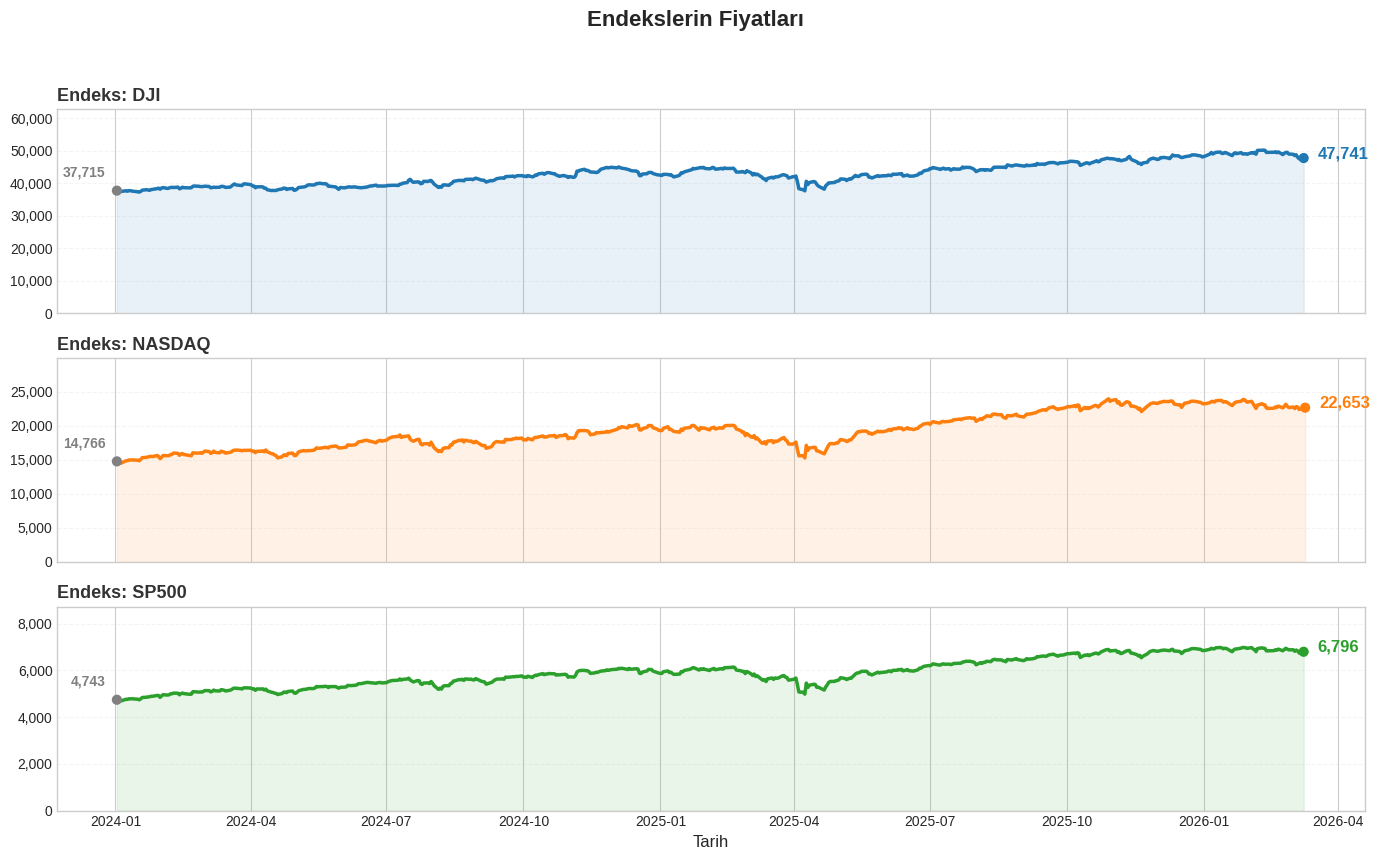

In [54]:
import matplotlib.pyplot as plt

def plot_index_subplots_with_labels(df, title, time_col):
    df_plot = df.set_index(time_col)
    num_cols = len(df_plot.columns)
    
    fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(14, 3 * num_cols), sharex=True)
    
    if num_cols == 1:
        axes = [axes]
    
    for i, column in enumerate(df_plot.columns):
        data = df_plot[column]
        valid_data = data.dropna() # Boş verileri eliyoruz
        
        if not valid_data.empty:
            first_date = valid_data.index[0]
            first_price = valid_data.iloc[0]
            last_date = valid_data.index[-1]
            last_price = valid_data.iloc[-1]
            y_max = data.max()
            
            axes[i].plot(df_plot.index, data, color='C'+str(i), linewidth=2.5)
            axes[i].fill_between(df_plot.index, data, alpha=0.1, color='C'+str(i))
            
            axes[i].set_ylim(0, y_max * 1.25) 
            
            axes[i].annotate(f'{first_price:,.0f}', 
                             xy=(first_date, first_price),
                             xytext=(-8, 10), textcoords='offset points',
                             fontweight='bold', color='gray', 
                             fontsize=10, ha='right')
            
            axes[i].annotate(f'{last_price:,.0f}', 
                             xy=(last_date, last_price),
                             xytext=(10, 0), textcoords='offset points',
                             fontweight='bold', color='C'+str(i),
                             fontsize=12)
            
            axes[i].scatter([first_date, last_date], [first_price, last_price], 
                            color=['gray', 'C'+str(i)], s=40, zorder=5)

        axes[i].set_title(f"Endeks: {column}", loc='left', fontsize=13, fontweight='bold', color='#333333')
        axes[i].grid(True, axis='y', alpha=0.2, linestyle='--')
        
        axes[i].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

    plt.xlabel('Tarih', fontsize=12)
    plt.suptitle(title, fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_index_subplots_with_labels(prices_index_pivot, "Endekslerin Fiyatları", 'price_time')

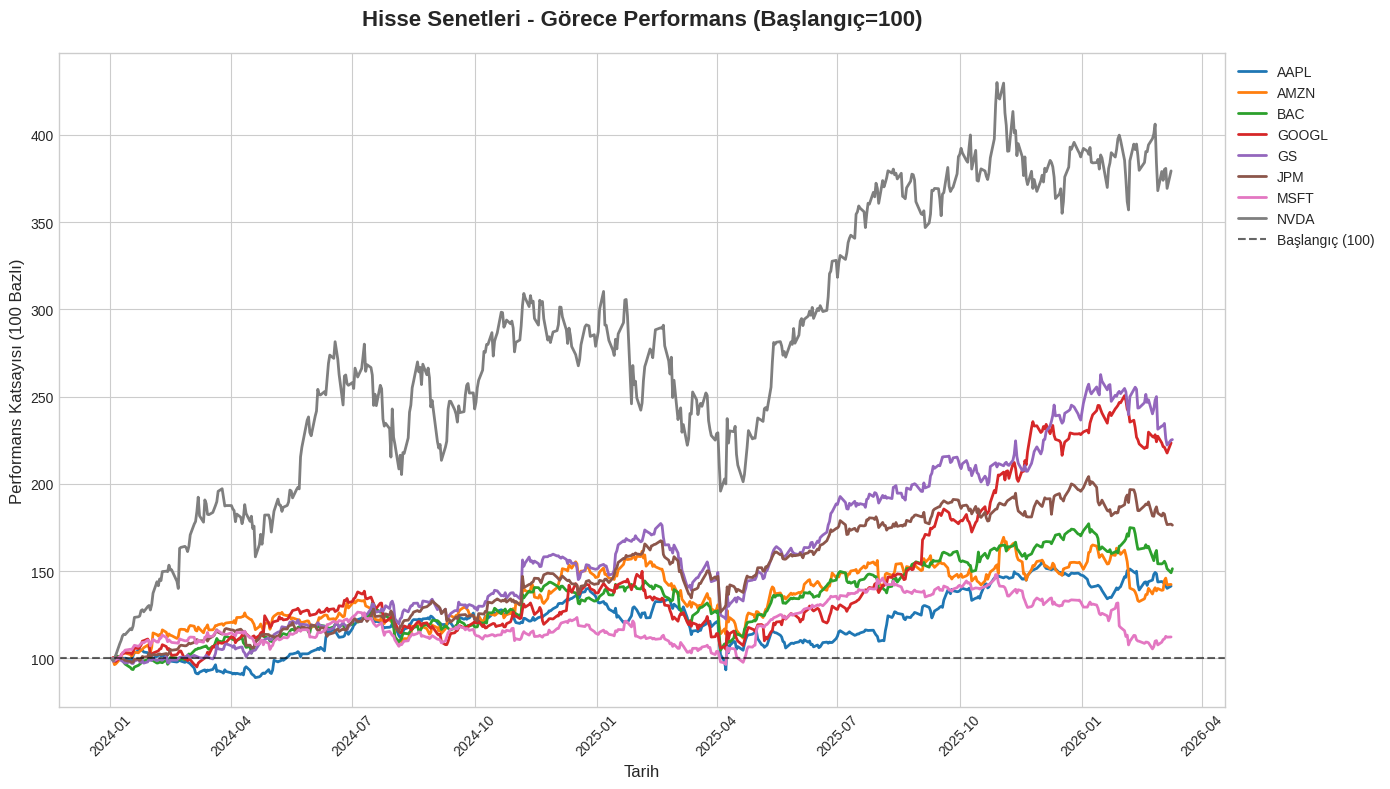

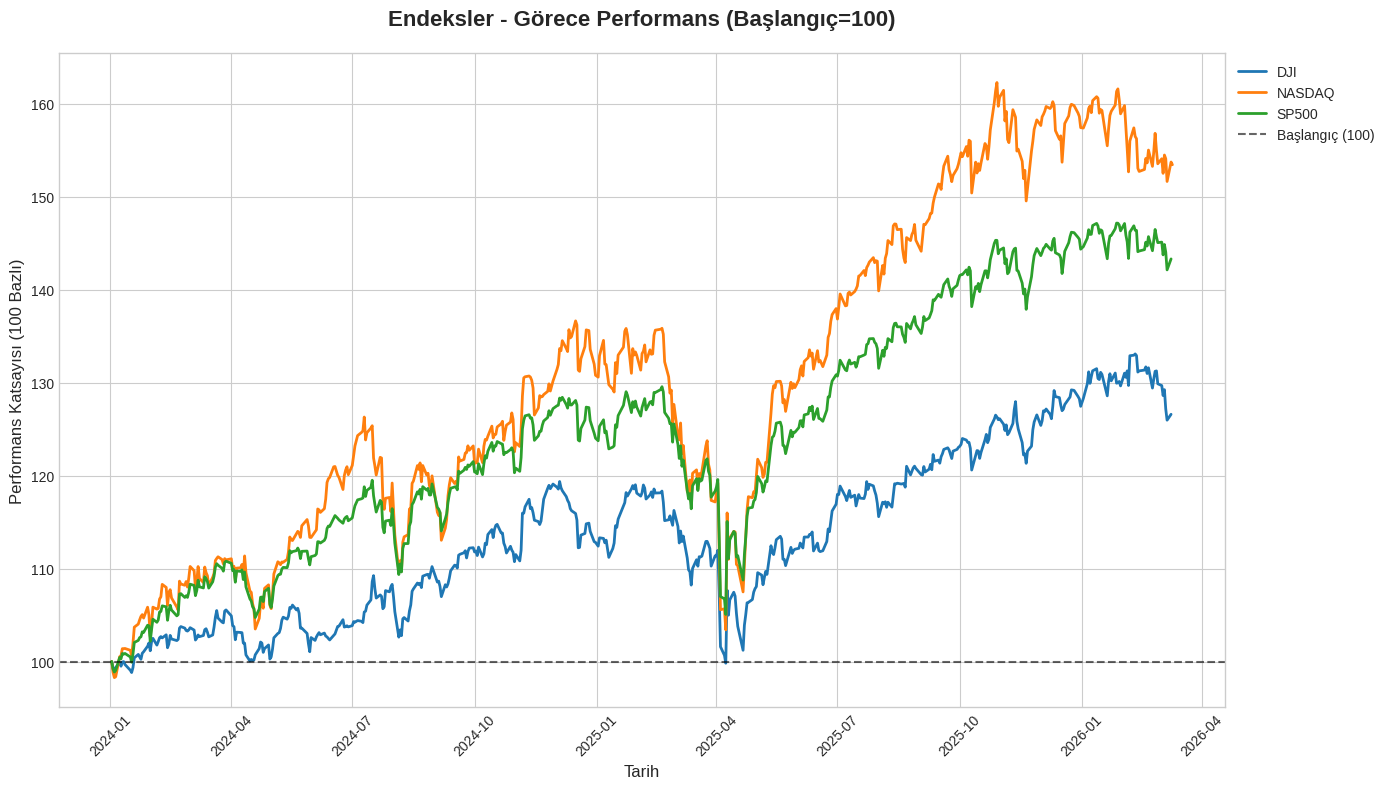

In [36]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

def plot_normalized_performance(df, title, time_col):
    df_plot = df.set_index(time_col).copy()
    
    normalized_df = (df_plot / df_plot.iloc[0]) * 100
    
    plt.figure(figsize=(14, 8))
    for column in normalized_df.columns:
        plt.plot(normalized_df.index, normalized_df[column], label=column, linewidth=2)
    
    plt.axhline(y=100, color='black', linestyle='--', alpha=0.6, label='Başlangıç (100)')
    
    plt.title(f"{title} - Görece Performans (Başlangıç=100)", fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Performans Katsayısı (100 Bazlı)', fontsize=12)
    plt.xlabel('Tarih', fontsize=12)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_normalized_performance(prices_stock_pivot, "Hisse Senetleri", 'price_time')

plot_normalized_performance(prices_index_pivot, "Endeksler", 'price_time')

In [50]:
import numpy as np
import pandas as pd
from IPython.display import display

def calculate_ultimate_scorecard(price_df, return_df, risk_free_rate=0.04):
    stats = []
    p_df = price_df.set_index(price_df.columns[0])
    r_df = return_df.set_index(return_df.columns[0])
    
    for ticker in p_df.columns:
        prices = p_df[ticker].dropna()
        returns = r_df[ticker].dropna()
        if len(prices) < 2: continue
            
        last_p = prices.iloc[-1]
        total_ret = (last_p / prices.iloc[0]) - 1
        daily_avg_ret = returns.mean()
        ann_return = daily_avg_ret * 252
        
        daily_vol = returns.std()
        ann_vol = daily_vol * np.sqrt(252)
        sharpe = (ann_return - risk_free_rate) / ann_vol
        
        var_90 = returns.quantile(0.10)
        var_95 = returns.quantile(0.05)
        
        max_dd = ((prices / prices.cummax()) - 1).min()
        
        stats.append({
            'Ticker': ticker,
            'Son Fiyat': last_p,
            'Toplam Getiri (%)': total_ret * 100,
            'Günlük Ort. Getiri (%)': daily_avg_ret * 100,
            'Sharpe Oranı': sharpe,
            'Risk Değeri (Günlük %)': daily_vol * 100,
            'Yıllık Volatilite (%)': ann_vol * 100,
            'VaR (%90)': abs(var_90) * 100,
            'VaR (%95)': abs(var_95) * 100,
            'Maks. Düşüş (%)': max_dd * 100
        })
    return pd.DataFrame(stats)

full_summary = pd.concat([
    calculate_ultimate_scorecard(prices_stock_pivot, returns_stock_pivot),
    calculate_ultimate_scorecard(prices_index_pivot, returns_index_pivot)
], ignore_index=True)
full_summary.index = full_summary.index + 1

max_ret = full_summary['Toplam Getiri (%)'].abs().max()

styled_summary = full_summary.style \
    .format({
        'Son Fiyat': '{:,.2f}$', 'Toplam Getiri (%)': '{:+.2f}%', 
        'Günlük Ort. Getiri (%)': '{:+.3f}%', 'Sharpe Oranı': '{:.2f}',
        'Risk Değeri (Günlük %)': '{:.2f}%', 'Yıllık Volatilite (%)': '{:.2f}%',
        'VaR (%90)': '{:.2f}%', 'VaR (%95)': '{:.2f}%', 'Maks. Düşüş (%)': '{:.2f}%'
    }) \
    .background_gradient(subset=['Toplam Getiri (%)'], cmap='RdYlGn', vmin=-max_ret, vmax=max_ret) \
    .background_gradient(subset=['Sharpe Oranı'], cmap='YlGn', vmin=0, vmax=2) \
    .background_gradient(subset=['VaR (%90)'], cmap='Reds') \
    .background_gradient(subset=['VaR (%95)'], cmap='Reds') \
    .set_caption("Çift Katmanlı Risk ve Performans Analizi")

display(styled_summary)

,Ticker,Son Fiyat,Toplam Getiri (%),Günlük Ort. Getiri (%),Sharpe Oranı,Risk Değeri (Günlük %),Yıllık Volatilite (%),VaR (%90),VaR (%95),Maks. Düşüş (%)
1,AAPL,259.88$,+41.45%,+0.057%,0.37,1.74%,27.66%,1.84%,2.75%,-33.36%
2,AMZN,213.49$,+42.39%,+0.062%,0.37,1.98%,31.36%,2.19%,2.89%,-30.88%
3,BAC,48.65$,+51.42%,+0.077%,0.61,1.58%,25.14%,1.53%,2.30%,-27.51%
4,GOOGL,306.36$,+123.56%,+0.145%,1.10,1.86%,29.59%,1.86%,2.62%,-29.81%
5,GS,833.08$,+125.41%,+0.150%,1.15,1.84%,29.18%,1.79%,2.48%,-30.90%
6,JPM,288.97$,+76.37%,+0.106%,0.93,1.54%,24.42%,1.41%,2.29%,-24.42%
7,MSFT,409.41$,+12.29%,+0.019%,0.03,1.49%,23.70%,1.56%,2.39%,-28.78%
8,NVDA,182.65$,+279.40%,+0.239%,1.12,3.15%,49.96%,3.30%,4.58%,-36.88%
9,DJI,"47,740.80$",+26.58%,+0.043%,0.49,0.89%,14.16%,0.95%,1.33%,-16.37%
10,NASDAQ,"22,653.38$",+53.42%,+0.075%,0.71,1.32%,20.92%,1.48%,2.18%,-24.32%
